In [1]:
import corner
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib
from gwpy.timeseries import TimeSeries
import math
import bilby
from bilby.gw.conversion import generate_all_bbh_parameters
from bilby.core import utils
import numpy as np
from gwosc import datasets
import h5py
import pesummary
from pesummary.io import read
from pesummary.core.plots.plot import _make_comparison_corner_plot
import seaborn as sns
import pandas as pd
import itertools
import argparse
import warnings
import os
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
from lal import LIGOTimeGPS
import datetime
import scipy
import json

plt.rcParams['axes.axisbelow'] = True

/home/hayato.imafuku/research/env/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
def make_pp_plot(path_to_outdirs, common_name=None ,file_num=None, show_plot=False):
    """setting"""
    matplotlib.rcParams['text.usetex'] = True  
    plt.rcParams['text.latex.preamble'] = r'\usepackage{mathrsfs}'

    latex_labels = {
        'mass_1_source' : r'$m_{1,\mathrm{source}}\ [M_{\odot}]$',    
        'mass_2_source' : r'$m_{2,\mathrm{source}}\ [M_{\odot}]$',    
        'mass_1' : r'$m_{1}\ [M_{\odot}]$',    
        'mass_2' : r'$m_{2}\ [M_{\odot}]$',    
        'chirp_mass_source' : r'$\mathcal{M}_{\mathrm{source}}\ [M_{\odot}]$',
        'chirp_mass' : r'$\mathcal{M}\ [M_{\odot}]$',
        'mass_ratio' : r'$q$',
        'total_mass_source' : r'$m_{\mathrm{total,source}}\ [M_{\odot}]$',
        'symmetric_mass_ratio' : r'$\eta$',
        'chi_1' : r'$\chi_{\rm 1}$',
        'chi_2' : r'$\chi_{\rm 2}$',
        'chi_eff' : r'$\chi_{\rm eff}$',
        'a_1' : r'$a_{1}$',
        'a_2' : r'$a_{2}$',
        'phi_12' : r'$\Delta\phi$',
        'phi_jl' : r'$\phi_{JL}$',
        'tilt_1' : r'$\theta_{1}$',
        'tilt_2' : r'$\theta_{2}$',
        'luminosity_distance' : r'$d_L\ [{\rm Mpc}]$',
        'theta_jn' : r'$\iota\ [{\rm rad}]$',
        'cos(iota)' : r'$\cos \iota$',
        'ra' : r'$ra$',
        'dec' : r'$dec$',
        'geocent_time' : r'$t_{c}$',
        'psi' : r'$\psi$',
        'phase' : r'$\phi$',
        'A_b1' : r'$A_{b1}$',
        'A_b2' : r'$A_{b2}$',
        'tilde_Ab1' : r'$\tilde{A}_{b1}$',
        'tilde_Ab2' : r'$\tilde{A}_{b2}$',
        'A1_real': r"$\mathrm{Re}[A_1] \times 10^{-20}$",
        'A1_imag': r"$\mathrm{Im}[A_1] \times 10^{-20}$",
        'alpha_real': r"$\mathrm{Re}[\alpha]$",
        'alpha_imag': r"$\mathrm{Im}[\alpha]$",
        'w1_real': r"$\mathrm{Re}[w_1]$",
        'w1_imag': r"$\mathrm{Im}[w_1]$",
        'w2_real': r"$\mathrm{Re}[w_2]$",
        'w2_imag': r"$\mathrm{Im}[w_2]$",
        'A': r'$A$',
        'A1': r'$A_1$',
        'A2': r'$A_2$',
        'alpha': r'$\alpha$',
        'f1': r'$f_1 \ [\mathrm{Hz}]$',
        'tau1': r'$\tau_1 \ [\mathrm{s}]$',
        'f2': r'$f_2 \ [\mathrm{Hz}]$',
        'tau2': r'$\tau_2 \ [\mathrm{s}]$',
        'phi1': r'$\phi_1$',
        'phi2': r'$\phi_2$',
    }

    """read json file"""            
    if common_name is not None:
        outdirs = []
        for i in range(0, int(file_num), 1):
            outdirs.append(common_name + '_v' + str(i))
    else:
        outdirs = {}
        for outdir in path_to_outdirs:
            outdirs[outdir] = os.listdir(outdir)

    main_dict = {}
    """read json file"""
    for path_to_outdirs, dirs in outdirs.items():
        for dir in dirs:
            files = os.listdir(os.path.join(path_to_outdirs, dir))
            for file in files:
                if file.endswith('.json'):
                    path_json_file = os.path.join(path_to_outdirs, dir, file)
                    break
                
            """get data from json file"""
            data = read(path_json_file, package = 'core')
            with open(path_json_file, 'r') as f:
                other_data = json.load(f)

            """read parameters"""
            posterior_df = data.samples_dict.to_pandas()
            injection_parameters = data.injection_parameters
            plot_keys = other_data['search_parameter_keys']
            # print('plot keys : {}'.format(plot_keys))
            """get poaterior less than injection"""
            for key in plot_keys:
                cumulative_posterior_less_than_injection = sum(np.array(posterior_df[key].values < injection_parameters[key])) / len(posterior_df) #(posterior<injection)_counts / all_counts
                if key not in main_dict.keys():
                    main_dict[key] = []
                main_dict[key].append(cumulative_posterior_less_than_injection)
    main_df = pd.DataFrame.from_dict(main_dict)
    print('main df : {}'.format(main_df))

    """counts results less than x"""
    plt.figure(dpi=200, figsize=(6, 4))
    x_values = np.linspace(0, 1, 1001)
    plt.plot([0, 1], [0, 1], 'k--')
    for ii, key in enumerate(main_df):
        pp = np.array([sum(main_df[key].values < xx) / len(main_df) for xx in x_values]) #(results<xx)_counts / all_counts
        pvalue = scipy.stats.kstest(main_df[key], 'uniform').pvalue #p-value for (posterior<injection) vs uniform_distribution
        label = "{} ({:2.3f})".format(latex_labels[key], pvalue)
        plt.plot(x_values, pp, label=label)
        print('pp : {}'.format(pp))
        print('p-value : {}'.format(pvalue))

    if file_num is not None:
        N = file_num
    else:
        N = len(main_df)
    print('event counts : {}'.format(N))
    """confidence interval"""
    confidence_interval = [0.68, 0.95, 0.997] #[1-2-3 sigma]
    confidence_interval_alpha = [0.2, 0.15, 0.1]
    for ci, alpha in zip(confidence_interval, confidence_interval_alpha):
        edge_of_bound = (1. - ci) / 2.
        lower = scipy.stats.binom.ppf(1 - edge_of_bound, N, x_values) / N
        upper = scipy.stats.binom.ppf(edge_of_bound, N, x_values) / N
        # The binomial point percent function doesn't always return 0 @ 0,
        # so set those bounds explicitly to be sure
        lower[0] = 0
        upper[0] = 0
        plt.fill_between(x_values, lower, upper, alpha=alpha, color='k')

    plt.xlabel('C.I.')
    plt.ylabel('fraction of events in C.I.')
    plt.grid(True)
    plt.legend()

    if show_plot:
        plt.show()
    else:
        save_file_name = './' + 'pp_one_mode_0-100' + 'pp_plot' + '.pdf'
        plt.savefig(save_file_name, bbox_inches="tight", pad_inches=0.05, dpi=200)

01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:59 bilby WARNING :

main df :           A1        f1      tau1      phi1
0   0.840945  0.448196  0.840768  0.128132
1   0.599857  0.207739  0.203281  0.628388
2   0.163903  0.009244  0.193690  0.204696
3   0.540721  0.705045  0.241081  0.595135
4   0.272727  0.246351  0.129418  0.123264
..       ...       ...       ...       ...
95  0.853160  0.140335  0.914126  0.718773
96  0.242256  0.067149  0.194955  0.954925
97  0.555576  0.233177  0.646111  0.883786
98  0.412251  0.160050  0.498832  0.722292
99  0.694621  0.208442  0.911281  0.407733

[100 rows x 4 columns]
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 0.6060724407399778
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 0.13251165964016717
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 0.8316392755766483
pp : [0.   0.01 0.01 ... 1.   1.   1.  ]
p-value : 0.7225985097170087
event counts : 100


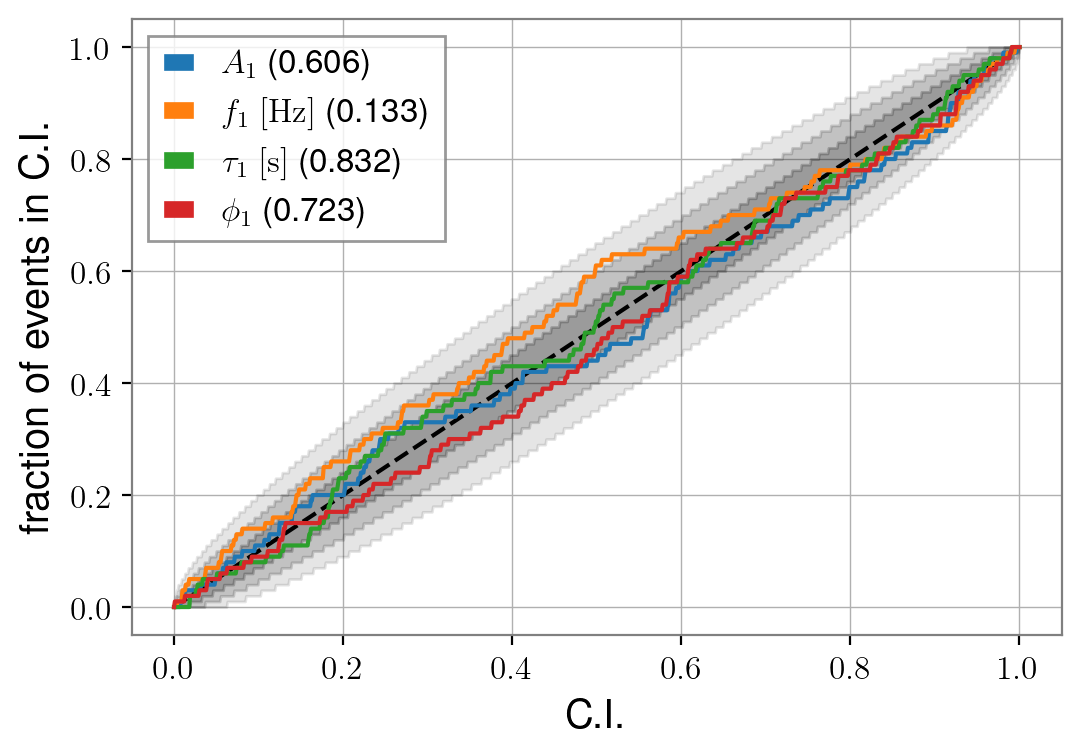

In [ ]:
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/pp_one_mode_0-100',]
make_pp_plot(path_to_outdirs, show_plot=True)

01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:14 bilby WARNING :

main df :           f1      tau1      phi1   A1
0   0.180716  0.722688  0.999465  0.0
1   0.396255  0.149606  0.998298  0.0
2   0.758135  0.370566  0.940340  0.0
3   0.967944  0.875000  0.000000  0.0
4   0.632877  0.021774  0.459120  0.0
..       ...       ...       ...  ...
95  0.292421  0.000000  0.907432  0.0
96  0.695035  0.314507  0.317988  0.0
97  0.642264  0.125982  0.283854  0.0
98  0.740048  0.101633  0.591635  0.0
99  0.071115  0.851587  0.286737  0.0

[100 rows x 4 columns]
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 0.18687763501152851
pp : [0.   0.03 0.04 ... 1.   1.   1.  ]
p-value : 1.464680305114975e-09
pp : [0.   0.1  0.1  ... 0.93 0.95 0.96]
p-value : 0.00295404815008979
pp : [0. 1. 1. ... 1. 1. 1.]
p-value : 0.0
event counts : 100


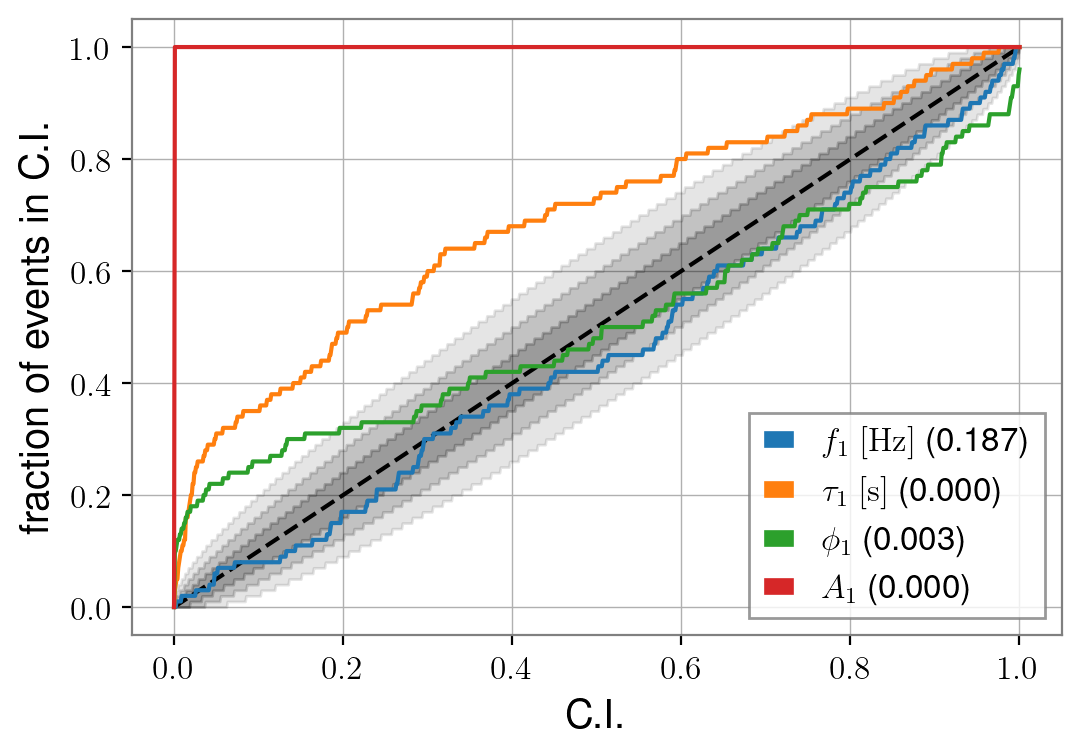

In [4]:
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/pp_one_mode_damp_analysis_APriLogUni',]
make_pp_plot(path_to_outdirs, show_plot=True)

12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
12:28 bilby WARNING :

main df :           A1        f1      tau1      phi1
0   0.000000  0.587868  0.042819  0.701754
1   0.000000  0.060872  0.237819  0.589958
2   0.000000  0.617159  0.186127  0.734239
3   0.000000  0.461477  0.263359  0.600096
4   0.613887  0.643089  0.722388  1.000000
..       ...       ...       ...       ...
95  0.000000  0.644075  0.437762  0.203022
96  0.156237  0.050300  0.415877  0.834690
97  0.298321  0.477178  0.213795  0.859574
98  0.000000  0.962625  0.148131  1.000000
99  0.000000  0.630606  0.329966  0.130606

[100 rows x 4 columns]
pp : [0.   0.77 0.77 ... 1.   1.   1.  ]
p-value : 9.536501954193575e-63
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 0.12588005113933937
pp : [0. 0. 0. ... 1. 1. 1.]
p-value : 3.501316696950885e-16
pp : [0.   0.11 0.11 ... 0.9  0.9  0.9 ]
p-value : 0.02241735248384016
event counts : 100


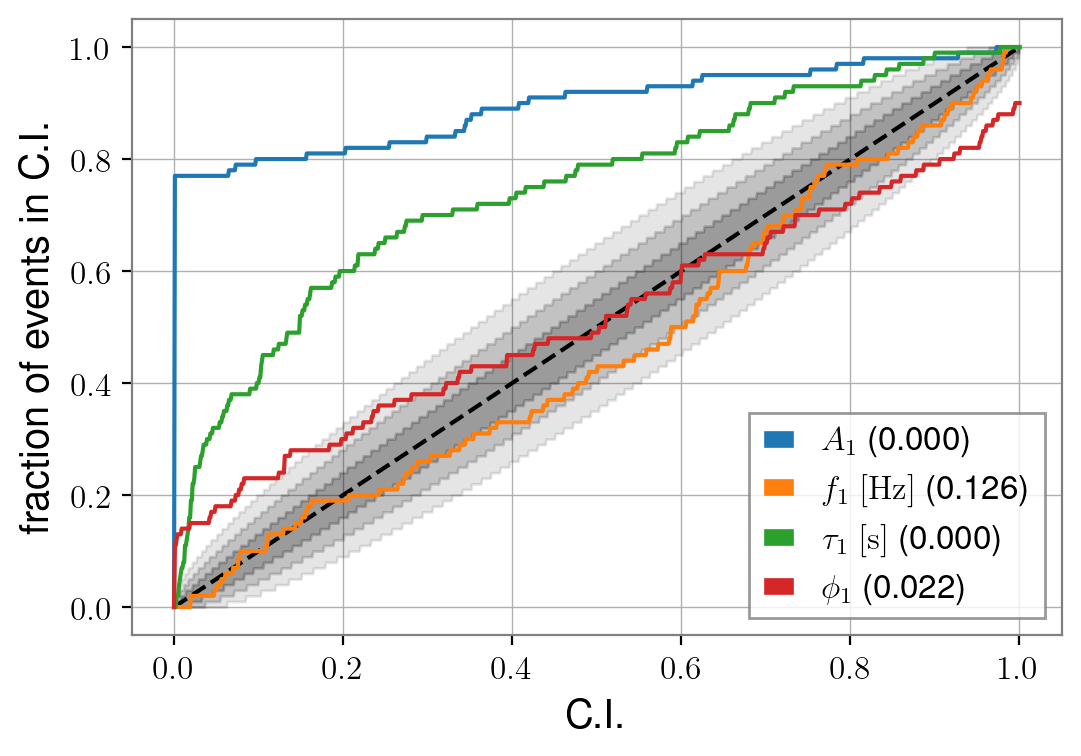

In [3]:
name = 'pp_one_mode_DSPram_APriLogUni'
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/{}/'.format(name),]
make_pp_plot(path_to_outdirs, show_plot=True)

17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
17:07 bilby WARNING :

main df :           A1        f1      tau1      phi1
0   0.378425  0.667660  0.287516  0.834346
1   0.152270  0.984752  0.150871  0.409666
2   0.424381  0.936755  0.651879  1.000000
3   0.688202  0.556960  0.829276  0.385768
4   0.360541  0.779602  0.188174  0.484116
..       ...       ...       ...       ...
95  0.103105  0.724920  0.009355  1.000000
96  0.471024  0.564340  0.356415  0.114608
97  0.106439  0.657797  0.080243  0.870812
98  0.176345  0.125097  0.334762  0.481878
99  0.000497  0.010601  0.390757  0.647838

[100 rows x 4 columns]
pp : [0.   0.01 0.01 ... 1.   1.   1.  ]
p-value : 1.8123919368847136e-14
pp : [0.   0.   0.   ... 0.99 1.   1.  ]
p-value : 0.18863417121956116
pp : [0.   0.01 0.02 ... 1.   1.   1.  ]
p-value : 0.032260010128666285
pp : [0.   0.11 0.11 ... 0.87 0.87 0.88]
p-value : 0.02865450145258065
event counts : 100


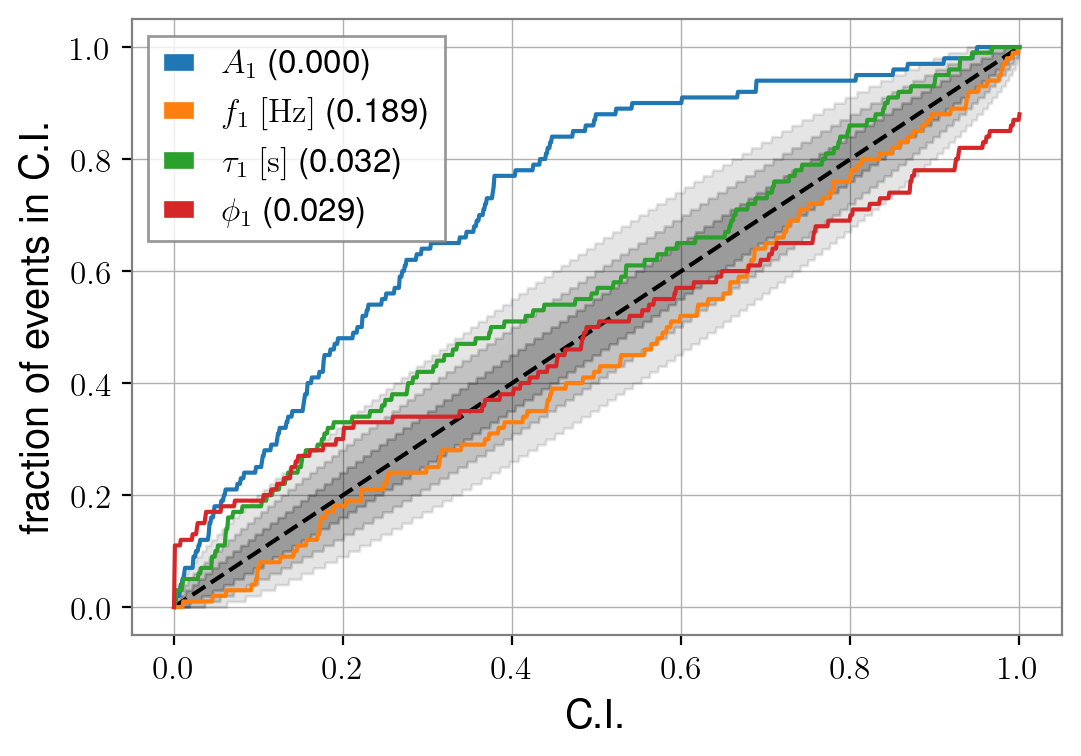

In [3]:
name = 'pp_one_mode_DSPram_APriUni'
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/{}/'.format(name),]
make_pp_plot(path_to_outdirs, show_plot=True)

00:17 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:17 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:17 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:17 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:17 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
00:18 bilby WARNING :

main df :           A1        A2        f1      tau1        f2      tau2      phi1  \
0   0.549168  0.257854  0.147456  0.042214  0.586422  0.556074  0.393444   
1   0.944298  0.498004  0.132048  0.375207  0.963482  0.939040  0.743695   
2   0.820295  0.310628  0.263748  0.719523  0.604227  0.256736  0.606531   
3   0.588632  0.133702  0.983702  0.159759  0.408753  0.666901  0.468109   
4   0.103879  0.621406  0.874852  0.392379  0.418964  0.601122  0.399961   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.562519  0.423050  0.815459  0.704161  0.293466  0.257982  0.847682   
96  0.869497  0.241690  0.010099  0.543485  0.930483  0.232964  0.124326   
97  0.654322  0.184185  0.890570  0.558546  0.279371  0.252161  0.757269   
98  0.772349  0.038157  0.836571  0.676016  0.274926  0.073043  0.817146   
99  0.937675  0.095848  0.614681  0.288508  0.442443  0.648011  0.043156   

        phi2  
0   0.530882  
1   0.399163  
2   0.111289  
3   0.920121  
4 

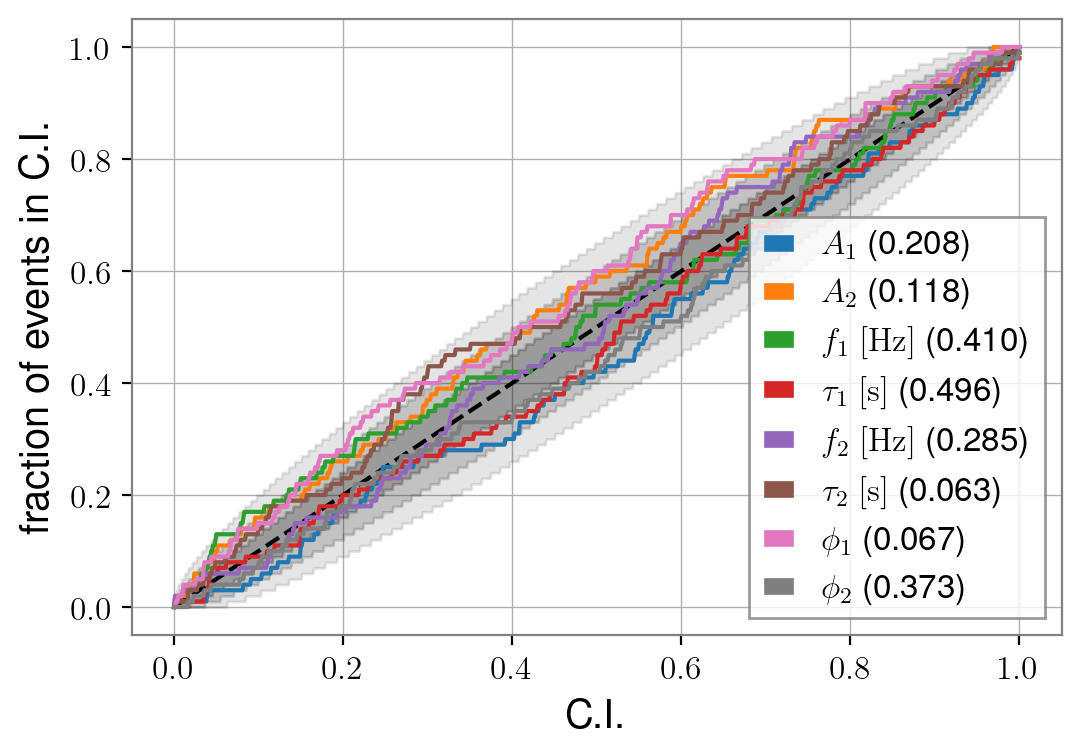

In [5]:
name = 'pp_two_mode_generated_by_DSPram'
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/{}/'.format(name),]
make_pp_plot(path_to_outdirs, show_plot=True)

18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
18:59 bilby WARNING :

main df :            A     alpha        f1        f2      tau1      tau2      phi1  \
0   0.035728  0.022851  0.034465  0.998990  0.931069  0.742962  0.419518   
1   0.075939  0.072740  0.925918  0.075217  0.064589  0.986690  0.124226   
2   0.301423  0.304787  0.905692  0.230013  0.776843  0.479301  0.804269   
3   0.392447  0.396147  0.180531  0.491579  0.745981  0.042485  0.336183   
4   0.360613  0.363451  0.912713  0.253575  0.311464  0.693757  0.255278   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.140543  0.121301  0.135428  0.638412  0.006333  0.934722  0.245403   
96  0.146888  0.141672  0.538708  0.572851  0.110729  0.528631  0.045406   
97  0.096725  0.096944  0.232798  0.285887  0.357221  0.100572  0.514838   
98  0.117096  0.114842  0.208210  0.076047  0.012694  0.587377  0.449401   
99  0.241375  0.237837  0.453782  0.580827  0.444604  0.904356  0.437749   

        phi2  
0   0.995455  
1   0.038382  
2   0.180207  
3   0.166624  
4 

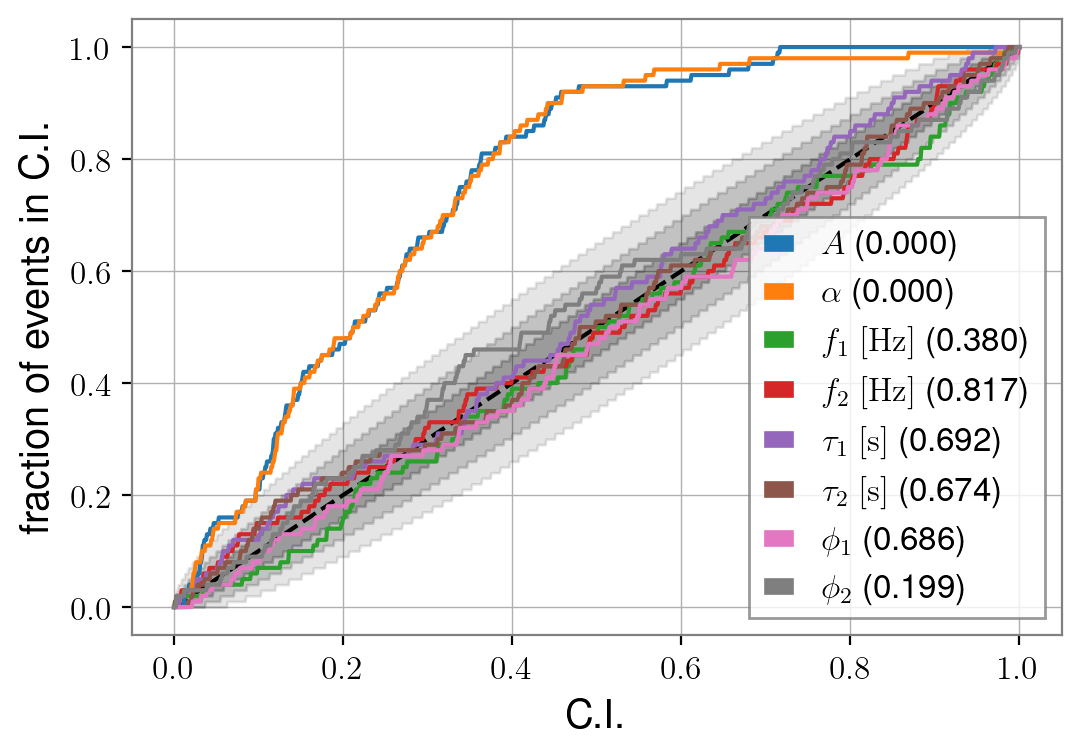

In [5]:
name = 'pp_two_mode_generated_by_OTparam'
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/{}/'.format(name),]
make_pp_plot(path_to_outdirs, show_plot=True)

01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:23 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:24 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:24 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:24 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:24 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.
01:24 bilby WARNING :

main df :            A     alpha        f1        f2      tau1      tau2      phi1  \
0   0.625317  0.625521  0.694504  0.121000  0.228690  0.275323  0.821498   
1   0.394769  0.392777  0.076650  0.489001  0.497055  0.912437  0.612420   
2   0.827938  0.827629  0.338144  0.404330  0.497835  0.084021  0.362268   
3   0.197876  0.198833  0.735336  0.563487  0.469812  0.002966  0.368099   
4   0.631994  0.630782  0.802262  0.646132  0.116239  0.313270  0.847304   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.004099  0.004099  0.984535  0.557574  0.001025  0.361561  0.981088   
96  0.087257  0.087057  0.532058  0.966139  0.164797  0.277099  0.823182   
97  0.168645  0.168645  0.105489  0.013137  0.051382  0.570553  0.178377   
98  0.923611  0.923382  0.852564  0.890415  0.689484  0.880723  0.863553   
99  0.193953  0.187731  0.665759  0.325588  0.272992  0.767451  0.317033   

        phi2  
0   0.114802  
1   0.686645  
2   0.172165  
3   0.873314  
4 

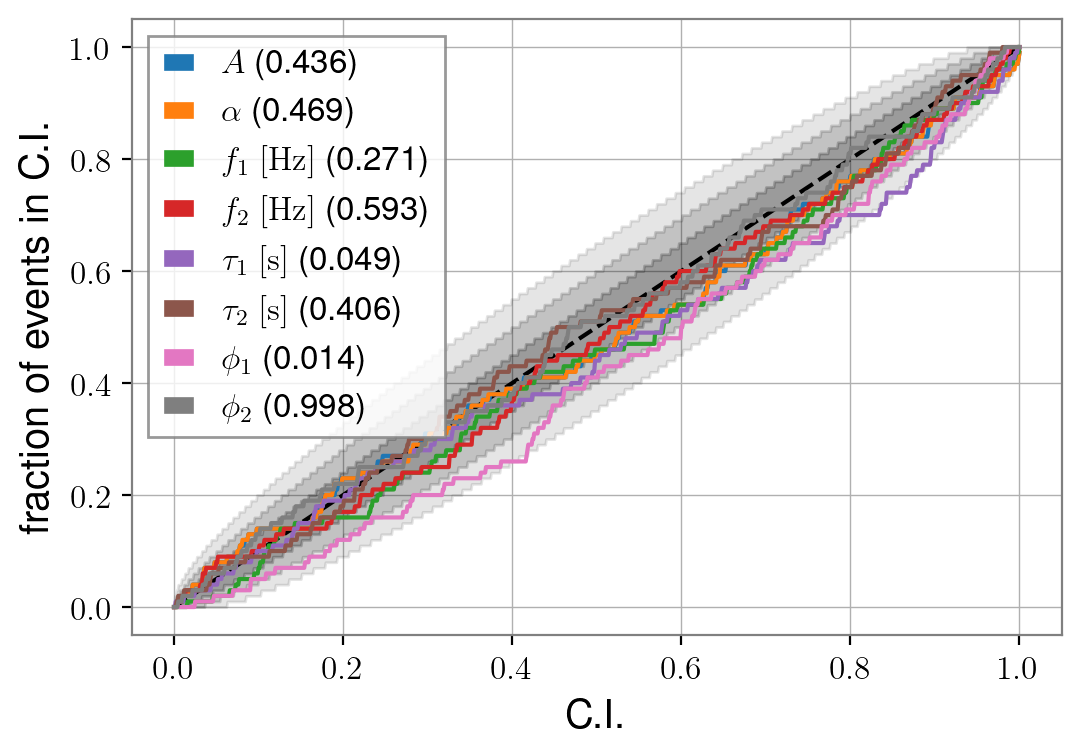

In [3]:
name = 'pp_two_mode_generated_by_OTparam_corrected'
path_to_outdirs = ['/home/hayato.imafuku/research/ringdown/pp_plot/outdirs/{}/'.format(name),]
make_pp_plot(path_to_outdirs, show_plot=True)